In [5]:
import os
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
import pandas as pd
import pickle
import gzip
import sys

def build_graph(coords, features, k=8, alpha=0.5, sigma_d=None):
    """
    构建结合空间与语义相似度的图。
    coords: (N, 2)  每个patch的(x, y)坐标
    features: (N, d) 每个patch的特征向量
    k: 每个节点的邻居数
    alpha: 空间与语义的融合比例
    sigma_d: 控制空间衰减的尺度
    """
    N = len(coords)
    if sigma_d is None:
        sigma_d = np.mean(np.std(coords, axis=0))  # 自适应尺度

    # Step 1. 基于空间的KNN
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # Step 2. 特征相似度矩阵
    feat_sim = cosine_similarity(features)

    edges, edge_weights = [], []
    for i in range(N):
        for j, dist in zip(indices[i, 1:], distances[i, 1:]):  # 跳过自己
            spatial_weight = np.exp(- (dist ** 2) / (2 * sigma_d ** 2))
            feature_weight = feat_sim[i, j]
            w_ij = alpha * spatial_weight + (1 - alpha) * feature_weight
            edges.append((i, j))
            edge_weights.append(w_ij)

    edges = np.array(edges)
    edge_weights = np.array(edge_weights)
    return edges, edge_weights


def to_pyg_data(features, coords, edges, edge_weights, labels=None):
    """转为 PyTorch Geometric Data 格式"""
    x = torch.tensor(features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    pos = torch.tensor(coords, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long) if labels is not None else None

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, pos=pos, y=y)
    return data


def main(features, coords, save_path, k=8, alpha=0.5):

    assert features.shape[0] == coords.shape[0], "Feature和坐标数量不一致！"

    # Step 2. 构建图
    print("Building graph...")
    edges, edge_weights = build_graph(coords, features, k=k, alpha=alpha)

    # Step 3. 转为PyG格式
    data = to_pyg_data(features, coords, edges, edge_weights)

    # Step 4. 保存
    torch.save(data, save_path)
    print(f"Graph saved to: {save_path}")
    print(f"节点数: {data.num_nodes}, 边数: {data.num_edges}")


if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser(description="Construct patch-level graph for WSI")
    parser.add_argument("--k", type=int, default=8, help="每个节点的邻居数")
    parser.add_argument("--alpha", type=float, default=0.5, help="空间与特征相似度融合比例")
    args, unknown = parser.parse_known_args(sys.argv[1:])

    basedir="/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like"
    root = os.path.join(basedir,"patch_grid_positions-TCGA_CESC-hospital.csv")
    file_info = pd.read_csv(root)
    cache_path = root.replace(".csv","_slide_patch_map.pkl.gz")
    embeddings_path = root.replace(".csv","_patch_embeddings-1024.pkl.gz")

    with gzip.open(embeddings_path, "rb") as f:
        embeddings_patch_map = pickle.load(f)
        embedding_slide = [i.split("_patch")[0] for i in embeddings_patch_map.keys()]
           
    slide_patch_map = {}
                        
    with gzip.open(cache_path, "rb") as f:
        slide_patch_map = pickle.load(f)
        slide_patch_map = {
            k: v
            for k, v in slide_patch_map.items()
            if k.rsplit("_", 1)[0] in embedding_slide
        }
            
        slide_names = list(slide_patch_map.keys())
        file_info = file_info[file_info['slide_name_split'].isin(slide_patch_map.keys())]
        
    for idx in range(len(slide_names)):   
        slide_name = file_info.iloc[idx]['slide_name_split']
        patch_paths = slide_patch_map[slide_name]

        patches = {}
        coords_x = []
        coords_y = []
        embeddings = []
        for patch_name in patch_paths:
            patch_name_tmp = patch_name.split("/")[-1]
#             print("check",patch_name_tmp)
            embedding_index = embeddings_patch_map[patch_name_tmp]
            embedding = np.load(embedding_index[0].replace("filenames_","features_"))['arr_0'][embedding_index[1]]
            embeddings.append(embedding)
            row = file_info[file_info["filepath"]==patch_name]
            coords_x.append(row['x'].values[0])
            coords_y.append(row['y'].values[0])
            
        args.save_path = os.path.join(basedir,"Graph-1024-251028",slide_name+".pt")
        os.makedirs(os.path.join(basedir,"Graph-1024-251028"),exist_ok=True)
        coords = np.stack([np.array(coords_x), np.array(coords_y)], axis=1)
        main(np.array(embeddings), coords, args.save_path, args.k, args.alpha)
        # break


Building graph...
Graph saved to: /home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Graph-1024-251028/TCGA-2W-A8YY-01A-01-TSA.E5237533-AB19-41FB-84D5-80C3FF6D30EF_0.pt
节点数: 1064, 边数: 8512


KeyboardInterrupt: 

In [17]:
import os
import numpy as np
import torch
import pandas as pd
import pickle
import gzip
import multiprocessing as mp
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
basedir="/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like"

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import numpy as np

def build_graph_thre(coords, features, k=8, alpha=0.5, sigma_d=None, sim_threshold=None):
    """
    coords: (N, 2) 或 (N, d)  坐标
    features: (N, F) 节点特征
    k: 每个节点的最近邻数量
    alpha: 空间与特征加权比例
    sigma_d: 空间权重的标准差
    sim_threshold: 保留边的最小加权相似度 (w_ij)
    """
    if coords.shape[0] < 2:
        return None, None
    
    N = len(coords)
    if sigma_d is None:
        sigma_d = np.mean(np.std(coords, axis=0))

    k_actual = min(k, coords.shape[0] - 1)
    nbrs = NearestNeighbors(n_neighbors=k_actual+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    feat_sim = cosine_similarity(features)
    edges, edge_weights = [], []

    for i in range(N):
        for j, dist in zip(indices[i, 1:], distances[i, 1:]):
            spatial_weight = np.exp(- (dist ** 2) / (2 * sigma_d ** 2))
            feature_weight = feat_sim[i, j]
            w_ij = alpha * spatial_weight + (1 - alpha) * feature_weight

            # 如果设置了阈值，则只保留大于阈值的边
            if sim_threshold is None or w_ij >= sim_threshold:
                edges.append((i, j))
                edge_weights.append(w_ij)

    return np.array(edges), np.array(edge_weights)

def build_graph(coords, features, k=8, alpha=0.5, sigma_d=None):
    if coords.shape[0] < 2:
        
        return None,None
    
    N = len(coords)
    if sigma_d is None:
        sigma_d = np.mean(np.std(coords, axis=0))

    k_actual = min(k, coords.shape[0]- 1)  # 保证 k <= n_samples
    nbrs = NearestNeighbors(n_neighbors=k_actual+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    feat_sim = cosine_similarity(features)
    edges, edge_weights = [], []
    for i in range(N):
        for j, dist in zip(indices[i, 1:], distances[i, 1:]):
            spatial_weight = np.exp(- (dist ** 2) / (2 * sigma_d ** 2))
            feature_weight = feat_sim[i, j]
            w_ij = alpha * spatial_weight + (1 - alpha) * feature_weight
            edges.append((i, j))
            edge_weights.append(w_ij)
    return np.array(edges), np.array(edge_weights)

def to_pyg_data(features, coords, edges, edge_weights, labels=None):
    x = torch.tensor(features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    pos = torch.tensor(coords, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long) if labels is not None else None
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, pos=pos, y=y)

def process_slide(args):
    slide_name,basedir, save_dir, k, alpha = args
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, slide_name+".pt")
    if os.path.exists(save_path):
        print(f"[{slide_name}] already exists")
        return 
    embeddings = np.load(os.path.join(basedir,slide_name+"_features.npy"))
    coords = np.load(os.path.join(basedir,slide_name+"_coords.npy"))
#     edges, edge_weights = build_graph(coords, np.array(embeddings), k=k, alpha=alpha)
    
    # Canonical builder: spatial KNN + distance cutoff, with two edge channels.
    from dinov2.data.datasets.graph_builder import build_graph
    edges, edge_weights = build_graph(coords, np.array(embeddings), k=k)
    if edges is None:
        print(f"Slide {slide_name} too small, skipped.")
        return 
    data = Data(
        x=torch.tensor(np.array(embeddings), dtype=torch.float),
        edge_index=torch.tensor(edges.T, dtype=torch.long),
        edge_attr=torch.tensor(edge_weights, dtype=torch.float),
        pos=torch.tensor(coords, dtype=torch.float),
    )

    torch.save(data, save_path)
    print(f"[{slide_name}] Graph saved: nodes={data.num_nodes}, edges={data.num_edges}")

In [19]:
def main():
    save_dir = os.path.join(basedir,"Graph-1024-251111-thre")
    os.makedirs(save_dir, exist_ok=True)
    # 构建多进程任务
    n_processes = 10
    args_list = []
    pool = mp.Pool(n_processes)
    for i in os.listdir(os.path.join(basedir,"embeddings-1024")):
        if i.endswith("_features.npy"):
            slide_name = i.split("_features.npy")[0]
            args_list.append([slide_name,os.path.join(basedir,"embeddings-1024"),save_dir,8,0.5])
    pool.map(process_slide, args_list)
    pool.close()
    pool.join()

if __name__ == "__main__":
    main()


KeyboardInterrupt: 

In [7]:
import os
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
import pandas as pd
import pickle
import gzip
import sys

import math

def sinusoidal_coord_embedding(coords, embed_dim=32):
    """
    coords: [N, 2]  每行是 (x, y)，NumPy 数组
    embed_dim: 输出维度
    返回: [N, embed_dim] 的 NumPy 数组
    """
    N = coords.shape[0]
    pe = np.zeros((N, embed_dim), dtype=np.float32)

    for i in range(embed_dim // 4):
        div_term = 10000 ** (2 * i / embed_dim)
        pe[:, 4*i]   = np.sin(coords[:,0] / div_term)
        pe[:, 4*i+1] = np.cos(coords[:,0] / div_term)
        pe[:, 4*i+2] = np.sin(coords[:,1] / div_term)
        pe[:, 4*i+3] = np.cos(coords[:,1] / div_term)

    return pe
    
def build_graph(coords, features, k=8, alpha=0.5, sigma_d=None):
    """
    构建结合空间与语义相似度的图。
    coords: (N, 2)  每个patch的(x, y)坐标
    features: (N, d) 每个patch的特征向量
    k: 每个节点的邻居数
    alpha: 空间与语义的融合比例
    sigma_d: 控制空间衰减的尺度
    """
    N = len(coords)
    if sigma_d is None:
        sigma_d = np.mean(np.std(coords, axis=0))  # 自适应尺度

    # Step 1. 基于空间的KNN
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # Step 2. 特征相似度矩阵
    feat_sim = cosine_similarity(features)

    edges, edge_weights = [], []
    for i in range(N):
        for j, dist in zip(indices[i, 1:], distances[i, 1:]):  # 跳过自己
            spatial_weight = np.exp(- (dist ** 2) / (2 * sigma_d ** 2))
            feature_weight = feat_sim[i, j]
            w_ij = alpha * spatial_weight + (1 - alpha) * feature_weight
            edges.append((i, j))
            edge_weights.append(w_ij)

    edges = np.array(edges)
    edge_weights = np.array(edge_weights)
    return edges, edge_weights


def to_pyg_data(features, coords, edges, edge_weights, labels=None):
    """转为 PyTorch Geometric Data 格式"""

    x = torch.tensor(features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    pos = torch.tensor(coords, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long) if labels is not None else None

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, pos=pos, y=y)
    return data


def main(features, coords, save_path, k=8, alpha=0.5):

    assert features.shape[0] == coords.shape[0], "Feature和坐标数量不一致！"

    # Step 2. 构建图
    print("Building graph...")
    edges, edge_weights = build_graph(coords, features, k=k, alpha=alpha)

    coord_embed = sinusoidal_coord_embedding(coords, embed_dim=32)
    node_features = torch.cat([features, coord_embed], dim=1)

    # Step 3. 转为PyG格式
    data = to_pyg_data(node_features, coords, edges, edge_weights)

    # Step 4. 保存
    torch.save(data, save_path)
    print(f"Graph saved to: {save_path}")
    print(f"节点数: {data.num_nodes}, 边数: {data.num_edges}")


if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser(description="Construct patch-level graph for WSI")
    parser.add_argument("--k", type=int, default=8, help="每个节点的邻居数")
    parser.add_argument("--alpha", type=float, default=0.5, help="空间与特征相似度融合比例")
    args, unknown = parser.parse_known_args(sys.argv[1:])

    basedir="/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like"
    root = os.path.join(basedir,"patch_grid_positions-TCGA_CESC-hospital.csv")
    file_info = pd.read_csv(root)
    cache_path = root.replace(".csv","_slide_patch_map.pkl.gz")
    embeddings_path = root.replace(".csv","_patch_embeddings-1024.pkl.gz")

    with gzip.open(embeddings_path, "rb") as f:
        embeddings_patch_map = pickle.load(f)
        embedding_slide = [i.split("_patch")[0] for i in embeddings_patch_map.keys()]
           
    slide_patch_map = {}
                        
    with gzip.open(cache_path, "rb") as f:
        slide_patch_map = pickle.load(f)
        slide_patch_map = {
            k: v
            for k, v in slide_patch_map.items()
            if k.rsplit("_", 1)[0] in embedding_slide
        }
            
        slide_names = list(slide_patch_map.keys())
        file_info = file_info[file_info['slide_name_split'].isin(slide_patch_map.keys())]
        
    for idx in range(len(slide_names)):   
        slide_name = file_info.iloc[idx]['slide_name_split']
        patch_paths = slide_patch_map[slide_name]

        patches = {}
        coords_x = []
        coords_y = []
        embeddings = []
        for patch_name in patch_paths:
            patch_name_tmp = patch_name.split("/")[-1]
#             print("check",patch_name_tmp)
            embedding_index = embeddings_patch_map[patch_name_tmp]
            embedding = np.load(embedding_index[0].replace("filenames_","features_"))['arr_0'][embedding_index[1]]
            embeddings.append(embedding)
            row = file_info[file_info["filepath"]==patch_name]
            coords_x.append(row['x'].values[0])
            coords_y.append(row['y'].values[0])
            
        args.save_path = os.path.join(basedir,"Graph-1024-251028-pos",slide_name+".pt")
        os.makedirs(os.path.join(basedir,"Graph-1024-251028-pos"),exist_ok=True)
        coords = np.stack([np.array(coords_x), np.array(coords_y)], axis=1)
        main(np.array(embeddings), coords, args.save_path, args.k, args.alpha)
        # break


KeyboardInterrupt: 

In [9]:
import os
import numpy as np
import pandas as pd
import pickle
import gzip
import multiprocessing as mp
basedir="/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like"
root = os.path.join(basedir,"patch_grid_positions-TCGA_CESC-hospital.csv")
file_info = pd.read_csv(root)
cache_path = root.replace(".csv","_slide_patch_map.pkl.gz")
embeddings_path = root.replace(".csv","_patch_embeddings-1024.pkl.gz")

with gzip.open(embeddings_path, "rb") as f:
    embeddings_patch_map = pickle.load(f)
    embedding_slide = [i.split("_patch")[0] for i in embeddings_patch_map.keys()]
           
with gzip.open(cache_path, "rb") as f:
    slide_patch_map = pickle.load(f)
    # slide_patch_map = {k: v for k, v in slide_patch_map.items() if k.rsplit("_", 1)[0] in embedding_slide}

# 过滤 slide
filtered_slide_patch_map = {}
for k, patch_paths in slide_patch_map.items():
    slide_id = k.rsplit("_", 1)[0]
    if slide_id not in embedding_slide:
        continue

    # 过滤 patch，只保留在 embeddings_patch_map 中的
    filtered_patches = [
        p for p in patch_paths
        if os.path.basename(p) in embeddings_patch_map
    ]
    if len(filtered_patches) > 0:
        filtered_slide_patch_map[k] = filtered_patches

slide_patch_map = filtered_slide_patch_map

slide_names = list(slide_patch_map.keys())
file_info = file_info[file_info['slide_name_split'].isin(slide_patch_map.keys())]

save_dir = os.path.join(basedir,"embeddings-1024")
os.makedirs(save_dir, exist_ok=True)

def save_slide_embeddings_coords(slide_name, save_dir):
    """
    slide_name: 当前 slide 名称
    patch_paths: 当前 slide 对应的 patch 文件路径列表
    file_info: 包含每个 patch 坐标信息的 DataFrame
    embeddings_patch_map: patch_name -> embedding 索引信息
    save_dir: 保存目录
    """
    patch_paths = slide_patch_map[slide_name]
    os.makedirs(save_dir, exist_ok=True)
    save_feat_path = os.path.join(save_dir, slide_name+"_features.npy")
    save_coord_path = os.path.join(save_dir, slide_name+"_coords.npy")

    if os.path.exists(save_feat_path) and os.path.exists(save_coord_path):
        print(f"[{slide_name}] features and coords already exist, skip")
        return

    coords_x, coords_y, embeddings = [], [], []
    for patch_path in patch_paths:
        patch_name_tmp = os.path.basename(patch_path)
        embedding_index = embeddings_patch_map[patch_name_tmp]
        embedding = np.load(embedding_index[0].replace("filenames_","features_"))['arr_0'][embedding_index[1]]
        embeddings.append(embedding)

        row = file_info[file_info["filepath"]==patch_path]
        coords_x.append(row['x'].values[0])
        coords_y.append(row['y'].values[0])

    coords = np.stack([np.array(coords_x), np.array(coords_y)], axis=1)
    embeddings = np.array(embeddings)

    np.save(save_feat_path, embeddings)
    np.save(save_coord_path, coords)
    print(f"[{slide_name}] saved features, coords")

def process_slide(args):
    # args 是 tuple: (slide_name, patch_paths, file_info, embeddings_patch_map, save_dir)
    save_slide_embeddings_coords(*args)

from tqdm import tqdm
import multiprocessing as mp

def main():
    save_dir = os.path.join(basedir,"embeddings-1024")
    os.makedirs(save_dir, exist_ok=True)

    n_processes = 2
    pool = mp.Pool(n_processes)

    args_list = [(slide_name, save_dir) for slide_name in slide_names]

    # tqdm + imap_unordered
    for _ in tqdm(pool.imap_unordered(process_slide, args_list), total=len(args_list)):
        pass  # 每个任务内部已经打印 slide 名称和 PID

    pool.close()
    pool.join()

if __name__ == "__main__":
    main()



 0%|          | 0/2188 [00:00<?, ?it/s]

KeyError: '114855_0722203758966_h_patch_00000.png'

[143401_0712091331707_h_0] saved features, coords
[145750_0824124206594_h_0] saved features, coords
[151114 (2)_0] saved features, coords
[15bbcde2a4e2cdb5_0] saved features, coords
[166907_226612_1_ca4b84d49d6a0c11_0] saved features, coords
[166920_226625_1_2fd11959dc0cc18a_0] saved features, coords
[166920_226625_1_9fc21e4c17d0c026_0] saved features, coords
[227799880dbe0444_0] saved features, coords


In [2]:
embeddings_patch_map["114855_0722203758966_h_patch_00000.png"]

KeyError: '114855_0722203758966_h_patch_00000.png'

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import gzip
import multiprocessing as mp
basedir="/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like"
root = os.path.join(basedir,"patch_grid_positions-TCGA_CESC-hospital.csv")
file_info = pd.read_csv(root)
cache_path = root.replace(".csv","_slide_patch_map.pkl.gz")
embeddings_path = root.replace(".csv","_patch_embeddings-1024.pkl.gz")

with gzip.open(embeddings_path, "rb") as f:
    embeddings_patch_map = pickle.load(f)
    embedding_slide = [i.split("_patch")[0] for i in embeddings_patch_map.keys()]

In [3]:
"114855_0722203758966_h" in embedding_slide

True

In [4]:
for i in embeddings_patch_map.keys():
    if "114855_0722203758966_h" in i:
        print(i)

114855_0722203758966_h_patch_00003.png
114855_0722203758966_h_patch_00004.png
114855_0722203758966_h_patch_00005.png
114855_0722203758966_h_patch_00006.png
114855_0722203758966_h_patch_00007.png
114855_0722203758966_h_patch_00009.png
114855_0722203758966_h_patch_00011.png


In [5]:
with gzip.open(cache_path, "rb") as f:
    slide_patch_map = pickle.load(f)
    # slide_patch_map = {k: v for k, v in slide_patch_map.items() if k.rsplit("_", 1)[0] in embedding_slide}

In [10]:
slide_patch_map["114855_0722203758966_h_0"]

['/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_00000.png',
 '/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_00001.png',
 '/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_00002.png',
 '/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_00003.png',
 '/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_00004.png',
 '/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_00005.png',
 '/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_00006.png',
 '/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Rawdata/hospital/114855_0722203758966_h_patch_0000

### graph 查看

In [1]:
import torch
from torch_geometric.data import Data

In [40]:
import os
basedir="/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Graph-1024-251111-thre/"
file = "b1bb434b52ae30d0_0.pt"
data = torch.load(os.path.join(basedir,file))

print(data)
print(data.x.shape,data.x.dtype)       # 节点特征矩阵
print(len(data.edge_index))    # 边索引
print(data.y)    
'''
x 是节点特征矩阵；
edge_index 是 2×544 的张量，代表每条边的起点和终点；
edge_attr 是每条边的属性（如果为 None，就说明没有额外的边权）；
pos 给出节点坐标，可直接用于画图；
y（标签）暂时是 None，说明这个图目前没有指定标签。
'''

Data(x=[4, 1024], edge_index=[0], edge_attr=[0, 1], pos=[4, 2])
torch.Size([4, 1024]) torch.float32
0
None


'\nx 是节点特征矩阵；\nedge_index 是 2×544 的张量，代表每条边的起点和终点；\nedge_attr 是每条边的属性（如果为 None，就说明没有额外的边权）；\npos 给出节点坐标，可直接用于画图；\ny（标签）暂时是 None，说明这个图目前没有指定标签。\n'

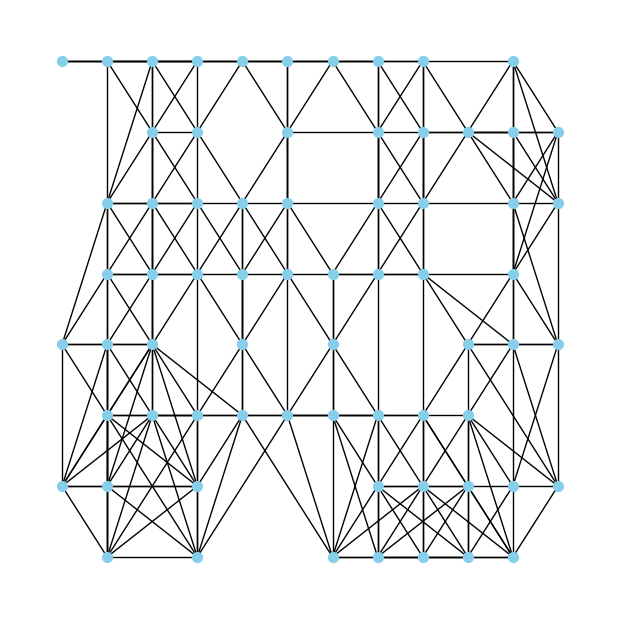

In [22]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

G = to_networkx(data, to_undirected=True)

plt.figure(figsize=(6,6))
nx.draw(G, pos=data.pos.numpy(), node_size=50, node_color='skyblue')
plt.show()


节点数: 68, 边数: 330
平均最近邻距离: 256.00
平均边长度: 304.84 ± 52.85
平均节点度: 4.85


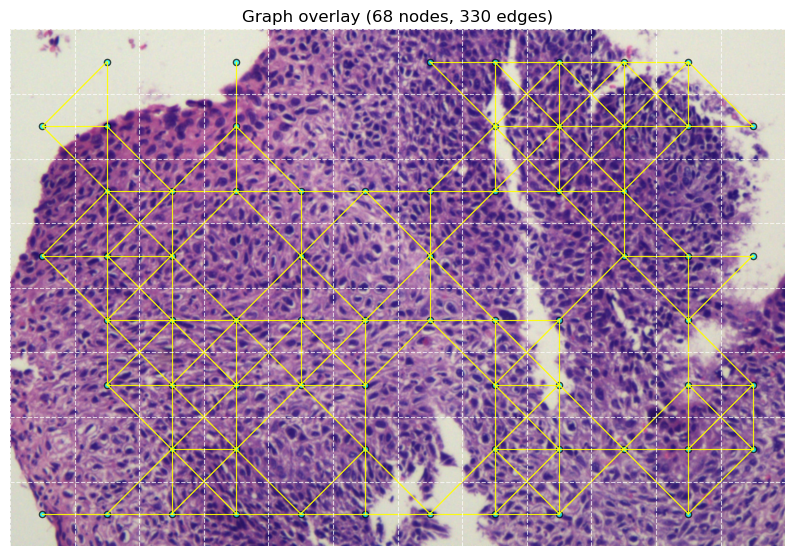

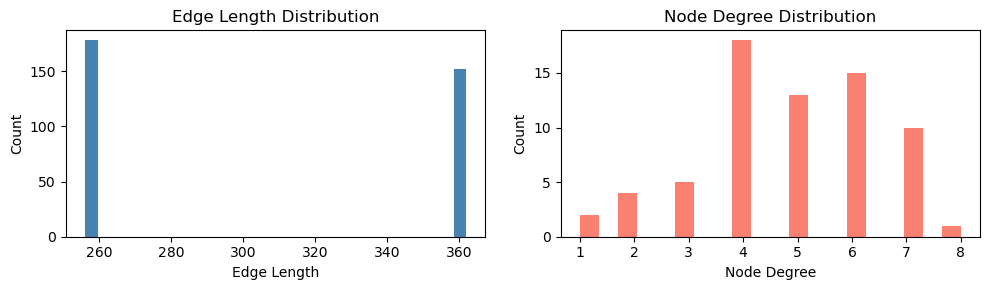

In [34]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.data import Data
from PIL import Image
from sklearn.neighbors import NearestNeighbors

basedir="/home/li_yu/Proj04_he/HE_DNAMeth/multimodel_data/HE/ImageNet_like/Graph-1024-251111-thre0.9/"
file = "126173_0615115446229_h_0.pt"
# ==== 用户输入 ====
image_path = os.path.join("/home/li_yu/Proj04_he/hospital_data_symlink/",file.replace("_0.pt",".jpg"))
graph_path = os.path.join(basedir,file)
save_path = file.replace(".pt",".jpg")
show_edges = True  # 是否画边
max_edges = 1000   # 避免过多边太密

# ==== 读取数据 ====
data: Data = torch.load(graph_path)
pos = data.pos.cpu().numpy()  # [N, 2]
edges = data.edge_index.cpu().numpy()
img = np.array(Image.open(image_path))

# ==== 基本信息 ====
print(f"节点数: {pos.shape[0]}, 边数: {edges.shape[1]}")

# ==== 图像与坐标归一化匹配 ====
# 假设 pos 已是图像空间坐标 (否则归一化到图像大小)
if np.max(pos[:, 0]) <= 1 and np.max(pos[:, 1]) <= 1:
    pos[:, 0] *= img.shape[1]
    pos[:, 1] *= img.shape[0]

# ==== 计算指标 ====
from scipy.spatial import distance_matrix

D = distance_matrix(pos, pos)
avg_nn_dist = np.mean([np.min(D[i, D[i]>0]) for i in range(len(pos))])
edge_lens = [D[i, j] for i, j in edges.T]
edge_len_mean = np.mean(edge_lens)
edge_len_std = np.std(edge_lens)
degree = np.bincount(edges[0], minlength=len(pos))

print(f"平均最近邻距离: {avg_nn_dist:.2f}")
print(f"平均边长度: {edge_len_mean:.2f} ± {edge_len_std:.2f}")
print(f"平均节点度: {np.mean(degree):.2f}")

# 假设 pos 是左上角坐标 (N, 2)
patch_size = 256
pos_center = pos + patch_size / 2  # 将点移动到patch中心

# ==== 可视化 ====
# plt.figure(figsize=(10, 10))
# plt.imshow(img)
# plt.scatter(pos_center[:, 0], pos_center[:, 1], s=20, c='cyan', alpha=0.7, edgecolors='k')

# if show_edges:
#     for idx, (i, j) in enumerate(edges.T):
#         if idx > max_edges: break
#         plt.plot([pos_center[i, 0], pos_center[j, 0]],
#                  [pos_center[i, 1], pos_center[j, 1]],
#                  color='yellow', alpha=0.7, linewidth=0.8)

# plt.title(f"Graph overlay ({pos_center.shape[0]} nodes, {edges.shape[1]} edges)")
# plt.axis('off')
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
# plt.show()

##
# ==== 可视化 + 256x256 网格 ====
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.scatter(pos_center[:, 0], pos_center[:, 1], s=20, c='cyan', alpha=0.7, edgecolors='k')

if show_edges:
    for idx, (i, j) in enumerate(edges.T):
        if idx > max_edges: break
        plt.plot([pos_center[i, 0], pos_center[j, 0]],
                 [pos_center[i, 1], pos_center[j, 1]],
                 color='yellow', alpha=0.7, linewidth=0.8)

# 绘制 256x256 网格
grid_size = 256
height, width = img.shape[:2]

for x in range(0, width, grid_size):
    plt.axvline(x=x, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
for y in range(0, height, grid_size):
    plt.axhline(y=y, color='white', linestyle='--', linewidth=0.8, alpha=0.7)

plt.title(f"Graph overlay ({pos.shape[0]} nodes, {edges.shape[1]} edges)")
plt.axis('off')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()


# ==== 可选：节点度与边长分布 ====
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.hist(edge_lens, bins=30, color='steelblue')
plt.xlabel('Edge Length')
plt.ylabel('Count')
plt.title('Edge Length Distribution')

plt.subplot(1, 2, 2)
plt.hist(degree, bins=20, color='salmon')
plt.xlabel('Node Degree')
plt.ylabel('Count')
plt.title('Node Degree Distribution')
plt.tight_layout()
plt.show()

